# 採点のしくみ — 何をすると点が上下するのか

このノートは、**PWS Cup 2026 の得点がどう決まるか**を、実際に匿名化データを何通りか作って
採点しながら確かめる教材です。所要 15〜20 分（全セル実行で約1分）。

> **これは任意の教材です。** ルールと採点の定義の正本は**ルールブック**です。
> 食い違ったらルールブックが正しいと考えてください。

**先に `はじめてのPWSCup.ipynb` を通しておくと分かりやすい**ですが、必須ではありません。
向こうは「提出まで1周やってみる」、こちらは「点数の中身を開けてみる」ノートです。

## このノートで分かること

1. 総合得点が **min（低いほうに合わせる）** で決まるとはどういうことか
2. 有用性 $U$ の4つの観点が、それぞれ**何を見ていて、どの操作で下がるのか**
3. **一番低い観点以外を直しても点は上がらない**（＝どこを直すべきか）
4. 匿名性がどう測られ、加工の強さとどう引き換えになるのか

## 動かし方

このノートは採点器そのものを import するので、`starter/` の環境が要ります。

```sh
cd starter
uv sync --extra notebook
uv run jupyter lab ..
```

> **このノートには実行結果を貼ったまま配布しています**（GitHub 上でそのまま読めるようにするため）。
> 手元で実行すると、環境によって最後の桁がわずかに違うことがあります。**公式記録は CodaBench の
> 採点結果です。**

## 0. 準備

In [1]:
import warnings, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# 配布データの場所を探す（リポジトリ配置でも zip 展開配置でも動くように）
DATA = next(p for p in (Path('..'), Path('../participant_data'), Path('participant_data'))
            if (p / 'B_practice.csv').exists())
sys.path.insert(0, str(Path('../starter/reference').resolve()))

from pwscup2026.kit import selfscore as ss          # ローカル自己採点（CodaBench と同じ採点器）
from pwscup2026.defense.perturb import perturb      # 単調にノイズを強めるノブ
from pwscup2026.defense.synth import copula_synth, copula_survival   # 参照防御の合成器
from pwscup2026.scoring.attack_score import score_mia, R_from_rate
from pwscup2026.rare import outlier as outlier_mod
from pwscup2026.common import schema
import _common

B  = pd.read_csv(DATA / 'B_practice.csv')                 # 加工の入力（あなたのコホート）
cfg = _common.load_cfg()                                  # 採点・検証パラメータ
B_ref, REF, CFG, info = ss.load_local_reference(DATA)     # 採点器が使う参照値
HORIZON = float(cfg['onset']['horizon_years'])

print(f'B: {B.shape[0]} 行 × {B.shape[1]} 列   追跡期間 horizon = {HORIZON} 年')
print(f'真の希少ラベル（B_self.csv）: {"あり" if info["b_self"] else "なし"}')

B: 1049 行 × 14 列   追跡期間 horizon = 10.0 年
真の希少ラベル（B_self.csv）: あり


## 1. 総合得点は「有用性と匿名性の低いほう」

$$\text{総合} \;=\; \min\bigl(\,U,\ \text{Anon}\,\bigr)$$

- $U$（有用性）… 匿名化データがどれだけ役に立つか。**手元で採点できます。**
- $\text{Anon}$（匿名性）… 攻撃されてどれだけ守れたか。他チームの攻撃が要るので**手元では採点できません**
  （このノートの後半で、代わりの自己診断をやります）。
- 攻撃得点は総合に畳まず、**別ランキング**（ベストアタック賞）です。

min なので、**片方だけ高くても勝てません**。元データをそのまま出せば $U=1$ ですが
$\text{Anon}=0$、乱数を出せば $\text{Anon}=1$ ですが $U=0$——どちらも総合は 0 です。

そして $U$ 自身も、さらに4つの観点の min です。

$$U \;=\; \min\bigl(\,U_\text{gen},\ U_\text{spec},\ U_\text{rare},\ U_\text{valid}\,\bigr)$$

| 観点 | ひとことで | 満足させたい相手 |
|---|---|---|
| $U_\text{gen}$ | データの見た目が本物っぽいか | データの分布を見る人 |
| $U_\text{spec}$ | 疫学解析をして**同じ結論**になるか | 発症要因を調べる研究者 |
| $U_\text{rare}$ | **数の少ない患者**が再現されているか | 希少疾患を調べる研究者 |
| $U_\text{valid}$ | データとして**破綻していない**か | 全員 |

**顧客が4人いて、誰か1人でも不満なら売り物にならない**——それが min-4 の意味です。

## 2. 採点を1行で呼べるようにする

`selfscore` は CodaBench のライブ採点と**同じ純関数**を呼びます。つまりここで出る数字は、
そのまま提出したときにサーバから返る数字です（`U` と4観点について）。

In [2]:
def score(C: pd.DataFrame) -> dict:
    """C を採点して {utility, facets, detail} を返す（CodaBench と同じ採点器）。"""
    return ss.self_score(C.copy(), B_ref, REF, CFG)

def facets_of(C, name):
    o = score(C)
    return {'加工': name, 'U': o['utility'], **o['facets']}, o

# まず「何も加工しない」を採点してみる（＝満点になるはず）
o0 = score(B)
print(f"無加工の U = {o0['utility']:.4f}")
print({k: round(v, 4) for k, v in o0['facets'].items()})

無加工の U = 1.0000
{'U_gen': 1.0, 'U_spec': 1.0, 'U_rare': 1.0, 'U_valid': 1.0}


満点です。当たり前に見えますが、大事なのは**「満点＝正解」ではない**ことです。
無加工は匿名性が 0 なので、総合は 0 になります。

## 3. 加工の型を5つ作って並べる

代表的な加工の型を作り、4観点がどこで崩れるかを見ます。

| 加工 | 中身 |
|---|---|
| 無加工 | `B` をそのまま |
| ノイズ | 連続列にガウスノイズ（`perturb` の強さ $k=0.3$） |
| 粗い丸め | 年齢10歳・検査値を粗い刻みに丸める（$k$-匿名化に近い発想） |
| 合成（転帰独立） | コピュラで共変量を作り直し、**転帰は共変量と無関係に**引く |
| 合成（転帰も条件付き） | 同上だが、転帰を**共変量から Cox でサンプル**する＝**参照防御** |

In [3]:
def coarse_round(df):
    """粗い丸め。k-匿名化に近い発想で、連続列を大きな刻みに寄せる。"""
    out = df.copy()
    for col, step in (('age',10),('BMI',5),('SBP',20),('TG',50),('HDL',20),('ALT',20),('FPG',20)):
        out[col] = np.round(out[col] / step) * step
    return out

VARIANTS = {
    '無加工':              B.copy(),
    'ノイズ k=0.3':        perturb(B, cfg, 0.3, np.random.default_rng(1)),
    '粗い丸め':            coarse_round(B),
    '合成(転帰独立)':      copula_synth(B, cfg, np.random.default_rng(2)),
    '合成(参照防御)':      copula_survival(B, cfg, np.random.default_rng(3)),
}

rows, DETAIL = [], {}
for name, C in VARIANTS.items():
    row, o = facets_of(C, name)
    rows.append(row); DETAIL[name] = o
tbl = pd.DataFrame(rows).set_index('加工').round(4)
F4 = ['U_gen','U_spec','U_rare','U_valid']
tbl['一番低い観点'] = np.where(tbl[F4].max(axis=1) - tbl[F4].min(axis=1) < 1e-9, '—', tbl[F4].idxmin(axis=1))
tbl

,U,U_gen,U_spec,U_rare,U_valid,一番低い観点
加工,,,,,,
無加工,1.0000,1.0000,1.0000,1.0000,1.0000,—
ノイズ k=0.3,0.6833,0.9556,0.6833,0.8128,0.7500,U_spec
粗い丸め,0.0320,0.7913,0.7124,0.0320,0.9994,U_rare
合成(転帰独立),0.2547,0.9743,0.3384,0.2547,1.0000,U_rare
合成(参照防御),0.3646,0.9762,0.4166,0.3646,1.0000,U_rare


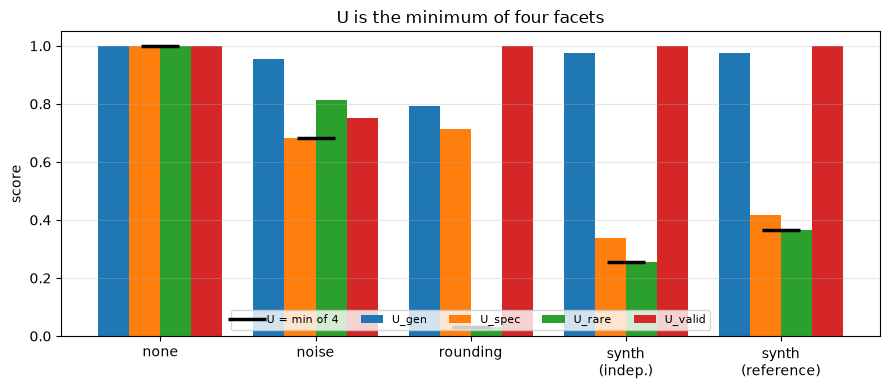

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
FACETS = ['U_gen','U_spec','U_rare','U_valid']
x = np.arange(len(tbl)); w = 0.2
for i, f in enumerate(FACETS):
    ax.bar(x + (i - 1.5) * w, tbl[f], w, label=f)
ax.plot(x, tbl['U'], 'k_', ms=28, mew=2.5, label='U = min of 4')
ax.set_xticks(x); ax.set_xticklabels(['none','noise','rounding','synth\n(indep.)','synth\n(reference)'])
ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.legend(ncol=5, fontsize=8, loc='lower center')
ax.set_title('U is the minimum of four facets')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

### 読み取り

- **黒い横棒（$U$）は、いつも一番低い棒の高さに一致します。** 他の3つがどれだけ高くても関係ありません。
- **加工の型ごとに、崩れる場所が違います。**

  | 加工 | min を握る観点 | 次に低い観点 |
  |---|---|---|
  | ノイズ | $U_\text{spec}$ 0.68 | $U_\text{valid}$ 0.75 |
  | 粗い丸め | $U_\text{rare}$ **0.03** | $U_\text{spec}$ 0.71 |
  | 合成（転帰独立） | $U_\text{rare}$ 0.25 | $U_\text{spec}$ 0.34 |
  | 合成（参照防御） | $U_\text{rare}$ 0.36 | $U_\text{spec}$ 0.42 |

  **弱点が散らばる**ように4観点は設計されています。「この加工をやっておけば安全」という
  単一の正解はありません。
- **$U_\text{gen}$ はどの加工でも 0.79 以上あります。** 見た目の一致だけなら、たいていの加工が
  通ってしまいます。**分布が似ていることは、有用であることの保証になりません。**

## 4. min の性質 —「一番低いところ」以外を直しても点は動かない

ここがこの競技で一番間違えやすいところです。実際にやってみます。

**ノイズ加工の弱点は $U_\text{valid}$ でした。** その中身は「打ち切りの整合」です。
このデータでは、**発症も死亡もしなかった人の `time` は追跡期間 10 年ちょうど**でなければ
なりません（10年間追いかけて何も起きなかった、という意味だからです）。
ところが `perturb` は `time` にもノイズを乗せるので、この論理が壊れます。

直し方は1行です。

In [5]:
def fix_censoring(C):
    """発症も死亡もしていない人の time を horizon に戻す（打ち切りの論理を復元）。"""
    out = C.copy()
    m = (out['onset'] == 0) & (out['death'] == 0)
    out.loc[m, 'time'] = HORIZON
    return out

C_noise = VARIANTS['ノイズ k=0.3']
before = DETAIL['ノイズ k=0.3']
after  = score(fix_censoring(C_noise))
d = before['detail']['U_valid']
print(f"打ち切りが正しい行の割合: {d['censoring_realism_rate']:.3f}  →  1.000")
print(f"U_valid : {before['facets']['U_valid']:.4f} → {after['facets']['U_valid']:.4f}")
print(f"U       : {before['utility']:.4f} → {after['utility']:.4f}   ★ほとんど動かない")

打ち切りが正しい行の割合: 0.500  →  1.000
U_valid : 0.7500 → 1.0000
U       : 0.6833 → 0.6839   ★ほとんど動かない


$U_\text{valid}$ は 0.75 から 1.00 へ**大きく改善したのに、$U$ はほぼ動きません**。
$k=0.3$ では $U_\text{spec}$（0.68）のほうが低く、そちらが min を握っていたからです。

では、ノイズを弱くして $U_\text{valid}$ が min になっている状態で同じことをすると——

In [6]:
C_light = perturb(B, cfg, 0.1, np.random.default_rng(1))
b2, a2 = score(C_light), score(fix_censoring(C_light))
cmp = pd.DataFrame({'修正前': {'U': b2['utility'], **b2['facets']},
                    '修正後': {'U': a2['utility'], **a2['facets']}}).round(4)
cmp['差'] = (cmp['修正後'] - cmp['修正前']).round(4)
print(cmp.to_string())
print(f"\n★ 同じ1行の修正で U が {b2['utility']:.4f} → {a2['utility']:.4f}（+{a2['utility']-b2['utility']:.4f}）")

            修正前     修正後       差
U        0.7593  0.9230  0.1637
U_gen    0.9789  0.9789  0.0000
U_spec   0.9238  0.9230 -0.0008
U_rare   0.9565  0.9565  0.0000
U_valid  0.7593  1.0000  0.2407

★ 同じ1行の修正で U が 0.7593 → 0.9230（+0.1637）


**同じ修正なのに、効果がまったく違います。**

| 状況 | 修正前の $U$ | 修正後の $U$ |
|---|---|---|
| $U_\text{valid}$ が min だった（$k=0.1$） | 0.759 | **0.923** |
| $U_\text{spec}$ が min だった（$k=0.3$） | 0.683 | 0.684 |

**教訓：自己採点で「一番低い観点」を見つけ、そこだけを狙って直してください。**
自己採点の出力にも `← ここが最も弱い` と印が出ます。他の観点をいくら磨いても $U$ は 1 ミリも動きません。

そして直すと**次の弱点が顔を出します**。$k=0.1$ を直したあとの min は $U_\text{spec}$（0.923）です。
これを繰り返して4観点を平らに持ち上げていくのが、有用性を上げる作業の形になります。

## 5. 観点の中身を開ける

`selfscore --json` や `detail` には、観点の**内訳**まで入っています。何が効いているかは
ここを見れば分かります。

### 5.1 $U_\text{gen}$ ＝ 3つの最小値（見た目の一致）

| 内訳 | 何を見ているか | 下がる操作 |
|---|---|---|
| `marginal_mean` | 10列（連続7＋カテゴリ3）の分布一致度の**平均** | 丸め・強いノイズ・値の打ち切り |
| `pmse` | 「本物か偽物か」を機械が当てられてしまわないか（**同時分布**） | 列間の相関を壊す |
| `time_dz` | 発症曲線（Kaplan–Meier）の形が合っているか | 発症時刻の分布をずらす |

> `marginal` は**最悪の列ではなく平均**です（$k$-匿名化のように1〜2列だけを大きく丸める加工を
> 過剰に罰しないため）。最悪列の値も `marginal_worst` として内訳に出ますが、**点数には入りません**。

In [7]:
g = pd.DataFrame({n: {'marginal_mean ★採点':  o['detail']['U_gen']['marginal_mean'],
                      'pmse ★採点':           o['detail']['U_gen']['pmse_score'],
                      'time_dz ★採点':        o['detail']['U_gen']['time_dz'],
                      '→ U_gen = min':        o['facets']['U_gen'],
                      '(参考) marginal_worst': o['detail']['U_gen']['marginal_worst']}
                  for n, o in DETAIL.items()}).round(4)
g

,無加工,ノイズ k=0.3,粗い丸め,合成(転帰独立),合成(参照防御)
marginal_mean ★採点,1.0,0.9556,0.7913,0.9743,0.9762
pmse ★採点,1.0,0.9976,0.9942,0.9970,0.9984
time_dz ★採点,1.0,1.0000,1.0000,1.0000,1.0000
→ U_gen = min,1.0,0.9556,0.7913,0.9743,0.9762
(参考) marginal_worst,1.0,0.8389,0.3403,0.9447,0.9333


### 5.2 $U_\text{spec}$ ＝ 2つの最小値（**解析の結論**の一致）

ここが**合成データの一番の弱点**です。見た目が本物そっくりでも、この観点は落ちます。

| 内訳 | 何を見ているか | 下がる操作 |
|---|---|---|
| `io_part` | Cox 回帰の**係数の信頼区間が本物と重なるか**。「何が発症に効くか」という解釈が変わらないか | 共変量と転帰の関係を壊す・弱める |
| `tstr_cal` | 匿名化データで学習したモデルが、本物のデータで**発症を当てられるか**（TSTR / c-index） | 転帰を共変量と無関係に生成する |

$U_\text{spec}$ は **Cox が収束しなければ 0** です（解析が成立しないデータが有用なはずはない、という考え方）。

In [8]:
s = pd.DataFrame({n: {'io_part(係数の重なり)': o['detail']['U_spec']['io_part'],
                      'tstr_cal(予測の再現)':  o['detail']['U_spec']['tstr_cal'],
                      'Cox収束':               o['detail']['U_spec']['cox_converged'],
                      '→ U_spec = min':        o['facets']['U_spec']}
                  for n, o in DETAIL.items()}).T
s[['io_part(係数の重なり)','tstr_cal(予測の再現)','→ U_spec = min']] = \
    s[['io_part(係数の重なり)','tstr_cal(予測の再現)','→ U_spec = min']].astype(float).round(4)
s

,io_part(係数の重なり),tstr_cal(予測の再現),Cox収束,→ U_spec = min
無加工,1.0000,1.0000,True,1.0000
ノイズ k=0.3,0.6833,1.0000,True,0.6833
粗い丸め,0.7124,0.9943,True,0.7124
合成(転帰独立),0.4363,0.3384,True,0.3384
合成(参照防御),0.4166,0.8961,True,0.4166


**2つの合成器を比べてください。**

- **転帰独立**：`tstr_cal` が 0.34 まで落ちます。転帰を共変量と無関係に引いたので、
  「FPG が高い人ほど発症する」という**予測に使える構造が消えた**からです。
- **参照防御（転帰も条件付き）**：`tstr_cal` は 0.90 まで回復しますが、今度は `io_part` が
  min になります。予測はできるようになっても、**係数の値そのもの**は本物とずれています。

つまり $U_\text{spec}$ を上げるには、「発症を当てられる」だけでは足りず、
**どの要因がどれだけ効くかまで合っている**必要があります。

### 5.3 $U_\text{rare}$ ＝ 4つの最小値（希少な患者の再現）

コホート 1,049 人のうち、希少な患者は **24 人（2.3%）** です。平均だけを見る指標では、
**この24人を消しても点数はほとんど動きません**。だから独立した観点にしてあります。

| 内訳 | 何を見ているか |
|---|---|
| `mass_star` | 希少と判定される人の**割合**が合っているか（多すぎても少なすぎても減点） |
| `prof_cal` | 希少群の検査値プロファイルの分布一致 |
| `onset_cal` | 希少群の**発症率**の一致 |
| `c2st_cal` | 希少群を機械が「本物/偽物」に判別できてしまわないか（同時分布の忠実度） |

**★ 希少を消して逃げることはできません。** $C$ 側で検出された希少が **8 人未満**なら、
`prof` / `onset` / `c2st` は**まとめて 0** になります（希少群の忠実度を検証できないため）。

In [9]:
r = pd.DataFrame({n: {'mass_star(割合)': o['detail']['U_rare']['mass_star'],
                      'prof_cal':        o['detail']['U_rare']['prof_cal'],
                      'onset_cal':       o['detail']['U_rare']['onset_cal'],
                      'c2st_cal':        o['detail']['U_rare']['c2st_cal'],
                      'C側の希少検出数':  o['detail']['U_rare']['rare_detected_C'],
                      '→ U_rare':        o['facets']['U_rare']}
                  for n, o in DETAIL.items()}).T
r

,mass_star(割合),prof_cal,onset_cal,c2st_cal,C側の希少検出数,→ U_rare
無加工,1.000000,1.000000,1.000000,1.000000,56.0,1.000000
ノイズ k=0.3,0.992173,0.946849,1.000000,0.812766,71.0,0.812766
粗い丸め,0.902887,0.827544,0.966812,0.031977,76.0,0.031977
合成(転帰独立),0.974315,0.823916,0.847134,0.254663,40.0,0.254663
合成(参照防御),0.956458,0.828839,0.932876,0.364609,39.0,0.364609


In [10]:
# 「希少っぽい行を消せば匿名性が上がるのでは？」を実際にやってみる
mah = outlier_mod.mahalanobis(B, REF.mu, REF.sigma, schema.CONTINUOUS)
C_dodge = B[mah < float(REF.band['lo'])].copy()
o_dodge = score(C_dodge)
dd = o_dodge['detail']['U_rare']
print(f'消したあとの行数      : {len(C_dodge)} / {len(B)}')
print(f'C側の希少検出数        : {dd["rare_detected_C"]}  （ゲート {dd["rare_gate"]} 人）')
print(f'0 にされた内訳         : {dd["u_rare_gated"]}')
print(f'U_rare = {o_dodge["facets"]["U_rare"]:.4f}   →   U = {o_dodge["utility"]:.4f}')

消したあとの行数      : 993 / 1049
C側の希少検出数        : 0  （ゲート 8 人）
0 にされた内訳         : ['prof_cal', 'onset_cal', 'c2st_cal']
U_rare = 0.0000   →   U = 0.0000


56 行を消しただけで **$U$ が 0** になりました。**希少を捨てる戦略は成立しません。**

逆に、`mass_star` は**多すぎても**減点されます。強いノイズをかけると外れ値が量産され、
希少と判定される人が 56 人 → 336 人のように膨らんで、やはり $U_\text{rare}$ が落ちます
（次節のスイープで見えます）。

### 5.4 $U_\text{valid}$ ＝ 2つの平均（データとしての妥当性）

ここだけ min ではなく**平均**です。

| 内訳 | 何を見ているか | 下がる操作 |
|---|---|---|
| `censoring_realism_rate` | 発症も死亡もしていない人の `time` が追跡期間ちょうどか | `time` にノイズを乗せる（§4 で見たとおり） |
| `no_fab` | **本物には無い群間差を作っていないか**（県・性別・喫煙 × 7指標＝21組を片側で罰す） | 群ごとに値をずらす・過度に平滑化して群差を誇張する |

`no_fab` は**片側**です。関係を弱めるぶんには罰しません（それは $U_\text{spec}$ の担当）。
罰するのは、**本物より強い関係を捏造した**ときだけです。

In [11]:
# 県ごとに FPG を人工的にずらす＝本物には無い群間差の捏造
C_fab = B.copy()
prefs = sorted(C_fab.prefecture.unique())
C_fab['FPG'] = C_fab.FPG + C_fab.prefecture.map({p: (i - len(prefs)/2) * 4.0 for i, p in enumerate(prefs)})
o_fab = score(C_fab)
print(f"no_fab  : {DETAIL['無加工']['detail']['U_valid']['no_fab']:.4f} (無加工) → {o_fab['detail']['U_valid']['no_fab']:.4f} (捏造)")
print(f"U_valid : {o_fab['facets']['U_valid']:.4f}")
print(f"U_rare  : {o_fab['facets']['U_rare']:.4f}  ← 外れ値が量産され希少判定が {o_fab['detail']['U_rare']['rare_detected_C']} 人に膨らんだ")
print(f"U       : {o_fab['utility']:.4f}")

no_fab  : 1.0000 (無加工) → 0.9524 (捏造)
U_valid : 0.9762
U_rare  : 0.0000  ← 外れ値が量産され希少判定が 447 人に膨らんだ
U       : 0.0000


$U_\text{valid}$ の下がり方は小さい（0.976）のに、**$U$ は 0** です。
値をずらしたことで外れ値が量産され、**$U_\text{rare}$ のほうが先に死んだ**からです。
**1か所の操作が複数の観点に波及する**——これも min-4 だと効いてきます。

## 6. ノイズを強くしていくと何が起きるか

`perturb` の強さ $k$ を 0 から 1 まで振って、4観点の動きを見ます。

      U_gen  U_spec  U_rare  U_valid       U  rare_detected_C
k                                                            
0.0  1.0000  1.0000  1.0000   1.0000  1.0000               56
0.1  0.9789  0.9238  0.9565   0.7593  0.7593               54
0.2  0.9671  0.8547  0.9437   0.7512  0.7512               60
0.4  0.9420  0.6021  0.7705   0.7483  0.6021               80
0.7  0.9112  0.4972  0.0000   0.7454  0.0000              152
1.0  0.8813  0.4932  0.0000   0.7448  0.0000              336


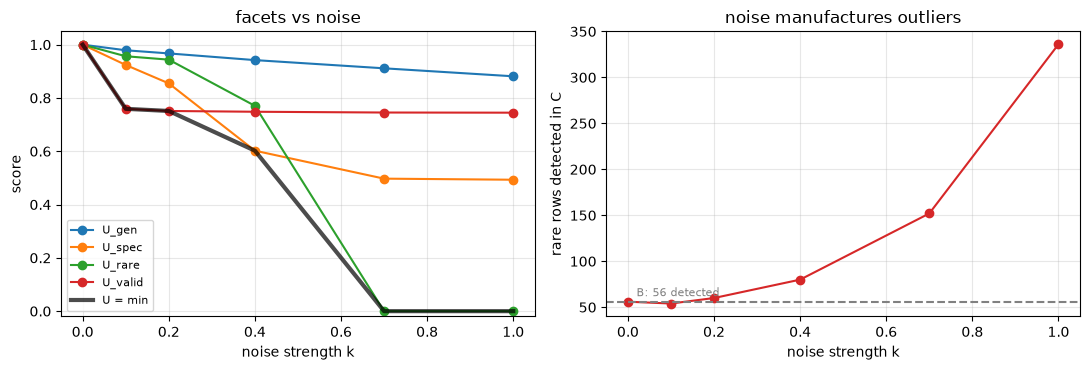

In [12]:
ks = [0.0, 0.1, 0.2, 0.4, 0.7, 1.0]
sw = []
for k in ks:
    C = perturb(B, cfg, k, np.random.default_rng(1)) if k > 0 else B.copy()
    o = score(C)
    sw.append({'k': k, **o['facets'], 'U': o['utility'],
               'rare_detected_C': o['detail']['U_rare']['rare_detected_C']})
sweep = pd.DataFrame(sw).set_index('k')
print(sweep.round(4).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for f in FACETS:
    ax1.plot(sweep.index, sweep[f], 'o-', label=f)
ax1.plot(sweep.index, sweep['U'], 'k-', lw=3, alpha=.7, label='U = min')
ax1.set_xlabel('noise strength k'); ax1.set_ylabel('score'); ax1.set_ylim(-.02, 1.05)
ax1.legend(fontsize=8); ax1.grid(alpha=.3); ax1.set_title('facets vs noise')
ax2.plot(sweep.index, sweep['rare_detected_C'], 'o-', color='tab:red')
ax2.axhline(56, ls='--', c='gray'); ax2.text(0.02, 62, 'B: 56 detected', fontsize=8, color='gray')
ax2.set_xlabel('noise strength k'); ax2.set_ylabel('rare rows detected in C')
ax2.grid(alpha=.3); ax2.set_title('noise manufactures outliers')
plt.tight_layout(); plt.show()

- $U_\text{valid}$ は **$k>0$ になった瞬間に落ちます**（打ち切りが壊れるので）。
  §4 の1行を足せば戻せる、いわば**ただの取りこぼし**です。
- $U_\text{rare}$ は **$k=0.4$ と $0.7$ のあいだで崖から落ちます**（0.83 → 0.00）。右の図のとおり、
  ノイズが外れ値を量産して希少判定が膨れ上がり、`mass_star` が 0 になるためです。
  **なだらかに悪化するのではなく、あるところで急に死にます。** 刻みを細かく振って崖の位置を
  探すのは、加工を作り込むうえで有効な手です。
- $U_\text{gen}$ は最後まで 0.88 以上あります。**「見た目が本物っぽい」だけでは何の保証にもなりません。**

## 7. 匿名性 Anon — 手元では採点できないが、目安は測れる

$$\text{Anon}(i) \;=\; 1 - \max\bigl(\ a_\text{MIA}(i)\ ,\ \ \max_{j} a_\text{AIA}(i;j)\ \bigr)$$

- **攻撃の種類の間では最悪ケース**。MIA と AIA のどちらか一方でも破られたら、そこで決まります。
- **MIA は攻撃者について平均**、**AIA は最大**。理由はルールブック §6.2.1 にあります。

### 7.1 MIA の目盛り — 「まぐれの何倍か」

MIA は「ある人が元データ $B$ に入っていたか」を当てる攻撃です。採点は
**FPR = 1%（ほとんど誤爆しない動作点）での的中率 TPR** で測ります。でたらめに順位を付けても
TPR は 0.01 になるので、**0.01 が「まぐれの水準」**です。そこを 0、その $K$ 倍を 1 とします。

$$a_\text{MIA} = \operatorname{clip}\bigl((\beta/0.01 - 1)/(K-1),\,0,\,1\bigr) \qquad (K = 12)$$

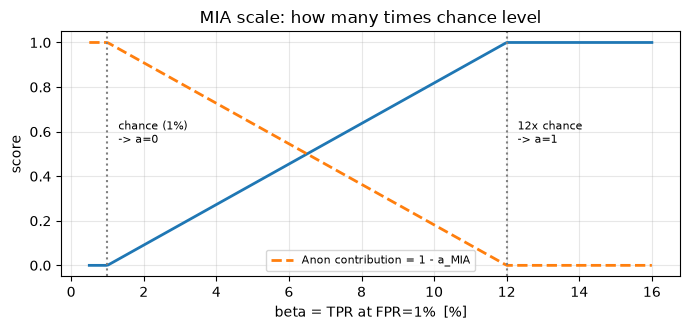

まぐれの水準の12倍（TPR=12%）当てられたら、匿名性のMIA成分は 0 になります。


In [13]:
beta = np.linspace(0.005, 0.16, 300)
K = 12
a_mia = np.clip((beta / 0.01 - 1) / (K - 1), 0, 1)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(beta * 100, a_mia, lw=2)
ax.plot(beta * 100, 1 - a_mia, lw=2, ls='--', label='Anon contribution = 1 - a_MIA')
for v, t in [(0.01, 'chance (1%)\n-> a=0'), (0.12, '12x chance\n-> a=1')]:
    ax.axvline(v * 100, color='gray', ls=':'); ax.text(v * 100 + .3, .55, t, fontsize=8)
ax.set_xlabel('beta = TPR at FPR=1%  [%]'); ax.set_ylabel('score'); ax.legend(fontsize=8)
ax.grid(alpha=.3); ax.set_title('MIA scale: how many times chance level'); plt.tight_layout(); plt.show()
print('まぐれの水準の12倍（TPR=12%）当てられたら、匿名性のMIA成分は 0 になります。')

実際の $\beta$ は、これに加えて **並べ替えによる「まぐれで届く水準」を実測して差し引き**ます
（20,000 回の並べ替えの95パーセンタイル）。メンバーが 25〜27 人しかいないため、
何も漏れていなくても偶然だけで 0.01 の数倍まで届いてしまうからです。
**「あなたのデータを見なくても得られた分は数えない」**——AIA で対照を混ぜるのと同じ考え方です。

### 7.2 自分の $C$ に自分で MIA を撃ってみる（自己診断）

本番の候補集合（誰が候補に挙がるか）は攻撃者しか知りませんが、**自分の $B$ は自分が持っています**。
そこで「$B$ の人（メンバー）＋ $A_\text{bg}$ の人（非メンバー）」を候補に見立て、
**$C$ の中の最も近い行までの距離**を確信度にして撃ってみます。

> これは**目安**で、採点の再現ではありません（候補集合も攻撃手法も本番とは違います）。
> それでも「無加工がどれだけ危ないか」は一撃で分かります。

In [14]:
from sklearn.neighbors import NearestNeighbors
QI = schema.CONTINUOUS
A_bg = pd.read_csv(DATA / 'A_bg.csv')

nonmem = A_bg.sample(n=len(B), random_state=7)
cand   = pd.concat([B[QI], nonmem[QI]], ignore_index=True)
truth  = np.r_[np.ones(len(B), int), np.zeros(len(nonmem), int)]
mu, sd = cand.mean().to_numpy(), cand.std(ddof=0).to_numpy()

def mia_probe(C):
    """C の中の最近傍までの距離を確信度にした素朴な MIA。β と a_MIA を返す。"""
    nn = NearestNeighbors(n_neighbors=1).fit((C[QI].to_numpy() - mu) / sd)
    dist, _ = nn.kneighbors((cand.to_numpy() - mu) / sd)
    res = score_mia(1.0 / (1.0 + dist.ravel()), truth, cfg)
    beta = res.breakdown['tpr_at_low_fpr']
    return beta, float(np.clip((beta / 0.01 - 1) / (12 - 1), 0, 1))

probe_rows = []
for name in ['無加工', 'ノイズ k=0.3', '合成(参照防御)']:
    beta, a = mia_probe(VARIANTS[name])
    u = DETAIL[name]['utility']
    probe_rows.append({'加工': name, 'U': round(u, 4), 'β=TPR@FPR1%': round(beta, 4),
                       'a_MIA': round(a, 3), 'Anon(目安)': round(1 - a, 3),
                       '総合=min(U,Anon)': round(min(u, 1 - a), 3)})
pd.DataFrame(probe_rows).set_index('加工')

,U,β=TPR@FPR1%,a_MIA,Anon(目安),"総合=min(U,Anon)"
加工,,,,,
無加工,1.0000,1.0000,1.000,0.000,0.000
ノイズ k=0.3,0.6833,0.0601,0.455,0.545,0.545
合成(参照防御),0.3646,0.0181,0.074,0.926,0.365


**これがこの競技の全体像です。**

- **無加工**：$U=1.00$ と満点でも、$C$ の中に本人の行がそのまま居るので最近傍距離が 0 になり、
  MIA が**満点で当たります**。$\text{Anon}=0$、総合 **0**。
- **ノイズ $k=0.3$**：両方が中途半端。総合は 0.55 前後。
- **参照防御（合成）**：MIA はほぼまぐれの水準まで落ちますが、今度は $U_\text{rare}$ が
  min を握って $U=0.36$。総合は **0.36**。

**どの型でも、$U$ と Anon のどちらかが必ず足を引っ張ります。** 有用性と匿名性の綱引きを
どこで釣り合わせるかが、この競技の設計問題です。

### 7.3 AIA の目盛り — 「対照を超えた分」

AIA（属性推論）は「伏せたはずの発症情報を当てられるか」です。得点は**的中率そのものではなく、
対照（そのチームのデータを見なくても当たる分）を超えた分**だけです。

$$R = \frac{p_m - p_c}{1 - p_c}$$

このノートでは深入りしません——**`はじめてのPWSCup.ipynb` の第5節**に数値例つきの説明があります。
ここでは採点器の関数をそのまま呼べることだけ示します。

In [15]:
def hits(p, n=100):
    """的中率 p の 0/1 配列を n 件ぶん作る。"""
    k = int(round(p * n)); return np.array([1] * k + [0] * (n - k))

for pm, pc, note in [(1.00, 0.50, '元データそのまま＝ほぼ全部当たる'),
                     (0.85, 0.80, '的中率85%でも、下駄が80%なら得点は 0.25 にしかならない'),
                     (0.50, 0.50, '対照と同じ＝何も分かっていない')]:
    R = R_from_rate(hits(pm), hits(pc))
    print(f'  p_m={pm:.2f}  p_c={pc:.2f}  →  R = {R:.2f}   {note}')

  p_m=1.00  p_c=0.50  →  R = 1.00   元データそのまま＝ほぼ全部当たる
  p_m=0.85  p_c=0.80  →  R = 0.25   的中率85%でも、下駄が80%なら得点は 0.25 にしかならない
  p_m=0.50  p_c=0.50  →  R = 0.00   対照と同じ＝何も分かっていない


## 8. 攻撃得点（別ランキング）

攻撃はメイン順位に畳まず、**ベストアタック賞**として別に集計します。

- 標的ごとに MIA と AIA の成功度を出し、**標的について単純平均**します。
- MIA 成分と AIA 成分を**足す**ので、攻撃得点は $[0, 2]$ の範囲です。
- **他チームの出来には依存しません。** 相対的な引き伸ばしも上限もありません。
  難しい標的も易しい標的も、同じ重みで数えます。

つまり攻撃側の戦略は単純で、**全標的に、対照を超える答えを出す**ことに尽きます。
1チームだけを深く破るより、広く当てるほうが得点になります。

## 9. まとめ — どこを触ると何が動くか

| 指標 | 何を測るか | 上がる操作 | 下がる操作 | 落とし穴 |
|---|---|---|---|---|
| $U_\text{gen}$ | 分布の見た目 | 周辺分布と相関を保つ | 粗い丸め・強いノイズ | ここが高くても他が低ければ無意味 |
| $U_\text{spec}$ | 解析の結論 | 共変量と転帰の関係を保つ | 転帰を独立に生成 | **Cox が収束しないと 0** |
| $U_\text{rare}$ | 希少患者の再現 | 希少を**同じ割合で**残す | 希少を消す／ノイズで外れ値を量産 | **C側の希少 8人未満で prof/onset/c2st が 0** |
| $U_\text{valid}$ | 破綻していないか | 打ち切りの論理を守る | `time` にノイズ・群間差の捏造 | 値域外の値は**採点以前に棄却** |
| $a_\text{MIA}$ | 会員が当てられるか | 元の行を残さない | 元データをほぼそのまま出す | まぐれの**12倍**で 0 |
| $a_\text{AIA}$ | 発症が当てられるか | 個人ではなく分布を再現する | 個人の転帰をそのまま残す | 対照を超えた分だけが数えられる |

### 手を動かす順番（おすすめ）

1. まず `selfscore` を回して、**一番低い観点**を見る（`← ここが最も弱い` の印）
2. その観点の内訳（このノートの §5）を見て、**どの内訳が落ちているか**を特定する
3. そこだけを狙って加工を変え、**もう一度 `selfscore`**
4. 直ったら**次の弱点**が出てくる。1に戻る

```sh
cd starter
uv run python -m pwscup2026.kit.selfscore ../C.csv --dist ../participant_data
```

匿名性は手元では採点できないので、**加工フェーズの「保護（protection）」の速報値**と、
§7.2 のような自己診断を目安にしてください（ただし保護は最終得点の匿名性の予告でも近似でもありません）。

---

分からないことがあれば、CodaBench の FAQ ページ、または事務局までご連絡ください。